In [2]:
import pathlib
import sys
import os

# Hacky way to get to root package
if "notebooks" in os.getcwd():
    os.chdir("..")

In [3]:
%load_ext autoreload
%autoreload 2
    
import sys
from data_container import load_scouted_data
import pandas as pd
import plotly.express as px
pd.set_option('display.max_columns', None)

In [4]:
scouted_data = load_scouted_data()

scouted_data['Team and Robot'] = scouted_data['Team and Robot'].astype(str)
scouted_data

,Scouter Initials,Match Number,Team and Robot,No Show,autoCarrotO,autoCarrotCakeO,autoCarrotL1,autoCarrotL2,autoCarrotL3,autoCarrotCakeL1,autoCarrotCakeL2,autoCarrotCakeL3,telCarrotO,telCarrotCakeO,telCarrotL1,telCarrotL2,telCarrotL3,telCarrotCakeL1,telCarrotCakeL2,telCarrotCakeL3,Auto Cross Kitchen Line,Auto Robot Stuck or Astop in Auto?,Harvest Haul Carrots,Harvest Haul Carrot Cakes
0,abc,1,3484,True,0,0,1,4,0,1,1,0,28,14,28,27,22,12,6,3,False,False,2,1
1,abc,1,63,False,0,0,1,0,2,1,0,1,22,6,19,4,23,16,20,15,False,False,0,0
2,abc,1,9406,False,4,2,1,2,0,0,1,0,10,19,23,12,30,12,16,12,False,False,1,1
3,abc,1,3504,False,2,0,1,3,4,2,1,2,4,10,3,18,26,15,10,7,False,False,0,0
4,abc,1,4467,False,3,1,3,1,1,0,2,2,2,4,13,1,29,0,19,7,False,False,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163,abc,33,4467,False,1,0,5,3,1,1,2,1,5,2,20,14,14,4,6,19,False,False,1,0
164,abc,33,9642,False,3,1,0,3,1,0,1,0,14,14,15,6,18,9,5,0,False,False,0,1
165,abc,33,2095,False,0,0,2,2,3,0,1,2,12,7,1,9,3,11,13,0,False,False,2,1
166,abc,33,4028,False,4,2,4,2,4,1,2,2,12,2,9,2,25,15,11,3,False,True,1,1


In [5]:
team_averages = scouted_data.groupby("Team and Robot").mean(numeric_only=True).reset_index()
team_averages

,Team and Robot,Match Number,No Show,autoCarrotO,autoCarrotCakeO,autoCarrotL1,autoCarrotL2,autoCarrotL3,autoCarrotCakeL1,autoCarrotCakeL2,autoCarrotCakeL3,telCarrotO,telCarrotCakeO,telCarrotL1,telCarrotL2,telCarrotL3,telCarrotCakeL1,telCarrotCakeL2,telCarrotCakeL3,Auto Cross Kitchen Line,Auto Robot Stuck or Astop in Auto?,Harvest Haul Carrots,Harvest Haul Carrot Cakes
0,10300,21.666667,0.000000,2.000000,0.666667,1.666667,1.333333,1.666667,0.333333,1.000000,1.000000,19.666667,10.333333,11.666667,11.333333,8.333333,11.666667,8.666667,14.666667,0.000000,0.000000,0.333333,1.000000
1,10512,22.333333,0.333333,3.333333,0.666667,3.333333,1.333333,1.333333,1.333333,1.000000,0.666667,20.666667,11.666667,15.666667,19.000000,18.333333,9.666667,10.000000,5.666667,0.000000,0.000000,0.333333,0.666667
2,10513,22.333333,0.333333,3.333333,1.000000,3.666667,1.666667,3.000000,1.333333,1.333333,1.000000,18.000000,14.666667,15.000000,8.333333,12.000000,9.000000,10.666667,6.666667,0.000000,0.000000,2.666667,0.666667
3,10515,21.666667,0.000000,1.666667,0.666667,3.000000,3.000000,3.000000,1.333333,0.333333,0.000000,21.666667,7.666667,19.666667,19.000000,14.666667,7.000000,11.000000,8.666667,0.000000,0.000000,2.000000,0.333333
4,10516,23.000000,0.000000,2.000000,0.333333,2.000000,3.666667,3.666667,1.000000,1.000000,0.333333,17.333333,9.000000,12.666667,22.666667,17.000000,13.333333,9.333333,12.666667,0.000000,0.000000,1.000000,0.333333
5,10517,22.333333,0.000000,4.000000,1.000000,2.000000,2.333333,3.000000,1.000000,0.333333,2.000000,14.333333,9.333333,13.333333,16.000000,9.000000,8.333333,5.666667,11.333333,0.333333,0.000000,2.000000,1.000000
6,10582,23.666667,0.000000,4.000000,0.666667,3.000000,1.333333,1.333333,1.333333,0.333333,1.666667,9.666667,11.333333,21.000000,13.000000,13.333333,7.666667,13.333333,13.000000,0.000000,0.000000,2.000000,0.333333
7,11456,24.000000,0.000000,3.333333,0.666667,0.333333,1.333333,1.666667,1.333333,0.666667,0.666667,22.000000,12.333333,14.000000,11.666667,16.000000,10.000000,10.000000,11.333333,0.000000,0.000000,2.333333,0.000000
8,117,17.500000,0.000000,2.250000,1.750000,2.500000,2.000000,2.250000,1.250000,1.000000,0.750000,19.000000,9.000000,16.750000,19.750000,5.000000,4.500000,9.500000,4.000000,0.000000,0.000000,2.000000,0.750000
9,1317,19.666667,0.000000,2.666667,0.666667,3.333333,0.666667,2.666667,1.000000,1.333333,1.000000,10.333333,17.333333,15.333333,21.000000,7.333333,11.333333,12.333333,9.333333,0.000000,0.000000,1.666667,0.333333


/Users/xiangjin/PycharmProjects/2026BunnyBotsScouting/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


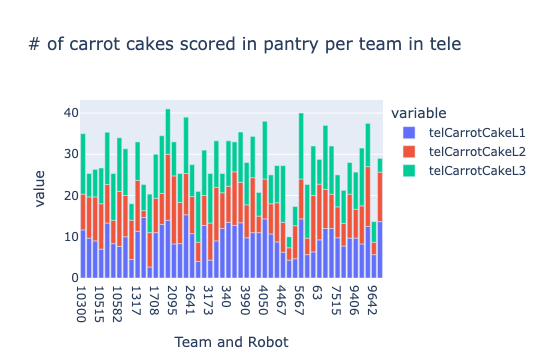

In [6]:
#L1, L2, L3 pantry carrot cake tele (stacked bar)
fig = px.bar(team_averages, x="Team and Robot", y=["telCarrotCakeL1", "telCarrotCakeL2", "telCarrotCakeL3"], title="# of carrot cakes scored in pantry per team in tele")
fig

In [17]:
#L1, L2, L3 pantry carrot cake auto (stacked bar)
teams_in_match = ["3504","340","3015","5667","4467"]
indices = team_averages["Team and Robot"].isin(teams_in_match)
small_team_averages=team_averages[indices]
fig = px.bar(small_team_averages, x="Team and Robot", y=["autoCarrotCakeL1", "autoCarrotCakeL2", "autoCarrotCakeL3"], title="# of cakes scored in pantry per team in auto")
fig

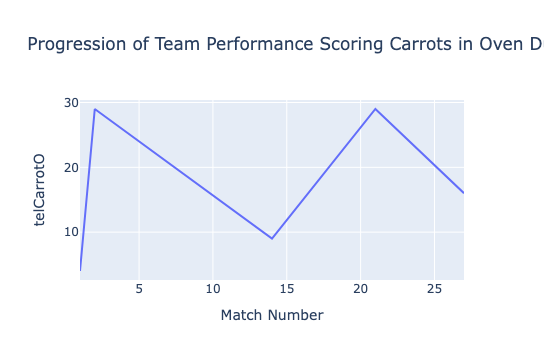

In [8]:
#oven carrot teleop for a team (area)
indices = scouted_data["Team and Robot"] == "3504"
teamdata = scouted_data[indices]
fig = px.line(teamdata, x="Match Number", y="telCarrotO", title="Progression of Team Performance Scoring Carrots in Oven During Teleop")
fig

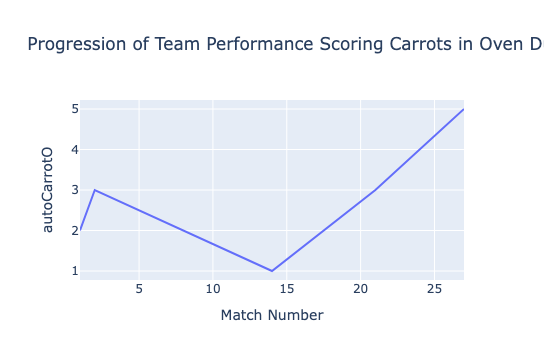

In [9]:
#oven carrot auto for a team (area)
indices=scouted_data["Team and Robot"]=="3504"
teamdata=scouted_data[indices]
fig = px.line(teamdata, x="Match Number",y="autoCarrotO", title="Progression of Team Performance Scoring Carrots in Oven During Auto")
fig

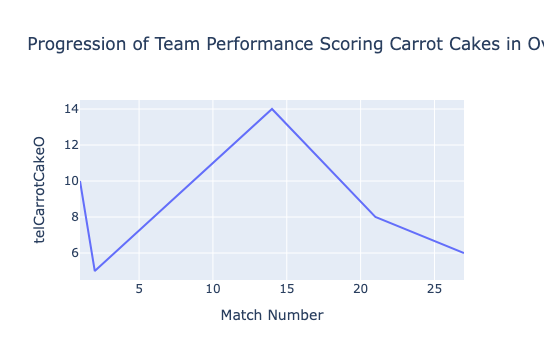

In [10]:
#oven carrot cake teleop for a team (area)
indices=scouted_data["Team and Robot"]=="3504"
teamdata=scouted_data[indices]
fig=px.line(teamdata,x="Match Number", y="telCarrotCakeO",title="Progression of Team Performance Scoring Carrot Cakes in Oven During Teleop")
fig

In [31]:
#oven carrot cake auto for a team (area)
indices=scouted_data["Team and Robot"]=="3504"
teamdata=scouted_data[indices]
fig=px.line(apple,x="Match Number", y="autoCarrotCakeO",title="Progression of Team Performance Scoring Carrot Cakes in Oven During Auto")
fig

ValueError: Boolean array expected for the condition, not object